In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)


In [13]:
fashion_mnist = fetch_openml(
    'Fashion-MNIST',
    version=1,
    as_frame=False
)

X = fashion_mnist.data
y = fashion_mnist.target.astype(int)

print(f"Total Dataset size:, {X.shape[0]} images,each with {X.shape[1]} pixels")
print(f"Target shape:", y.shape)

Total Dataset size:, 70000 images,each with784 pixels
Target shape: (70000,)


In [22]:
X_subset,_,y_subset,_=train_test_split(
    X,y,train_size =12000,
    random_state=42,
    stratify=y
)

X_train,X_test,y_train,y_test=train_test_split(X_subset,y_subset,test_size=2000,stratify=y_subset,random_state=42)
print("Training data:", X_train.shape[0])
print("Testing image:", X_test.shape[0])

Training data: 10000
Testing image: 2000


In [23]:
print(f"Before Scaling-> Min {X_train.min()},Max{X_train.max()}")
X_train = X_train / 255.0
X_test = X_test / 255.0
print(f"After Scaling -> Min:{X_train.min()}, Max:{X_train.max()}")


Before Scaling-> Min 0,Max255
After Scaling -> Min:0.0, Max:1.0


In [37]:
results = {}

k_values = [1, 3, 5, 7, 9,15]

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        n_jobs=-1
    )

    start_time = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = knn.predict(X_test)
    test_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)

    results[k] = {
        "accuracy": accuracy,
        "train_time": train_time,
        "test_time": test_time
    }

    print(
        f"K={k}, "
        f"Accuracy={accuracy * 100:.2f}%, "
        f"Prediction Time={test_time:.2f}s"
    )

    print(f"Prediction Time: {test_time:.4f} seconds")


K=1, Accuracy=79.30%, Prediction Time=0.22s
Prediction Time: 0.2244 seconds
K=3, Accuracy=80.90%, Prediction Time=0.19s
Prediction Time: 0.1941 seconds
K=5, Accuracy=81.00%, Prediction Time=0.20s
Prediction Time: 0.1966 seconds
K=7, Accuracy=81.10%, Prediction Time=0.20s
Prediction Time: 0.1966 seconds
K=9, Accuracy=80.95%, Prediction Time=0.20s
Prediction Time: 0.2012 seconds
K=15, Accuracy=80.25%, Prediction Time=0.20s
Prediction Time: 0.2041 seconds


In [36]:
class_names = ["TShirt/top","Trousers","PullOver","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
best_k = max(results,key=lambda k:results[k]["accuracy"])
print(f"Best K is: {best_k} with {results[best_k]['accuracy'] * 100:2f}% accuracy\n")


Best K is: 7 with 81.100000% accuracy



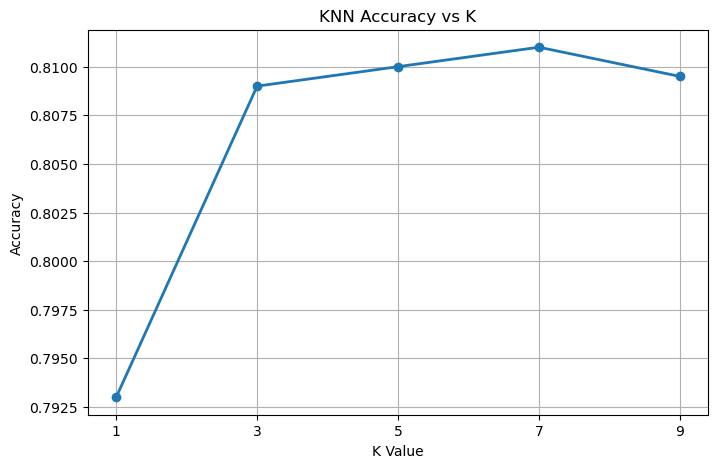

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(k_values)
plt.grid(True)

plt.show()
